# Synthetic Dataset Samples

This notebook renders one **rotated** and one **rotated + mirrored** example for the Tetris and colored-shapes datasets.
For the maze dataset, it shows a full path vs. a partial (uncompleted) trace.


In [14]:
import random
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import torch
import kornia as K

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

def plot_pair_grid(pairs, title, row_titles=None, col_titles=("Original", "Target")):
    n_rows = len(pairs)
    fig, axes = plt.subplots(n_rows, 2, figsize=(5.2, 2.6 * n_rows))
    if n_rows == 1:
        axes = np.array([axes])

    for r, (orig, target) in enumerate(pairs):
        ax = axes[r, 0]
        ax.imshow(orig, interpolation="nearest")
        ax.axis("off")

        ax = axes[r, 1]
        ax.imshow(target, interpolation="nearest")
        ax.axis("off")

        if row_titles:
            axes[r, 0].set_ylabel(row_titles[r], rotation=0, labelpad=40, va="center")

    if col_titles:
        axes[0, 0].set_title(col_titles[0])
        axes[0, 1].set_title(col_titles[1])

    fig.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()

def rotate_image_np(img, angle_deg, mode="bilinear"):
    img = np.ascontiguousarray(img)
    t = torch.from_numpy(img).float()
    if t.dim() == 2:
        t = t.unsqueeze(0).unsqueeze(0)
    else:
        t = t.permute(2, 0, 1).unsqueeze(0)
    angle = torch.tensor([float(angle_deg)])
    t_rot = K.geometry.transform.rotate(
        t, angle, mode=mode, padding_mode="zeros", align_corners=False
    )
    if img.ndim == 2:
        return t_rot[0, 0].cpu().numpy()
    return t_rot[0].permute(1, 2, 0).cpu().numpy()



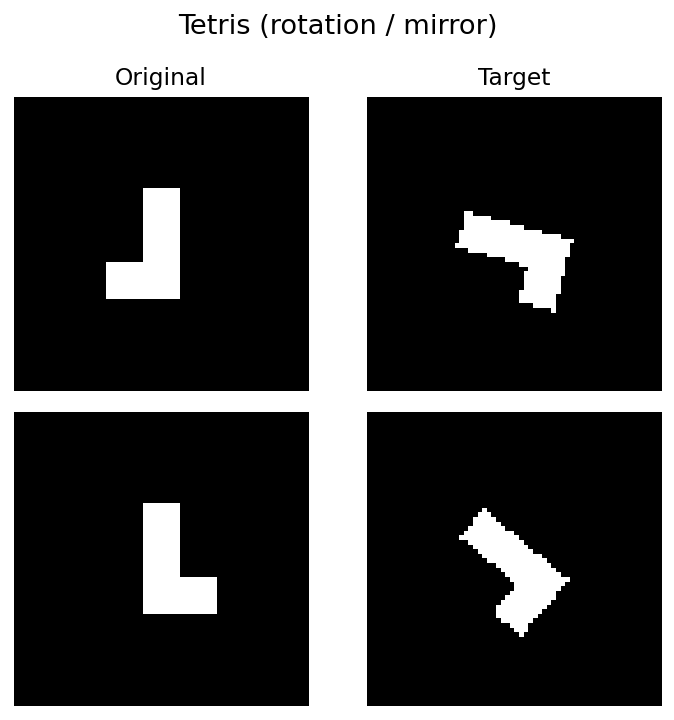

In [15]:
# --- Tetris dataset (rotation + optional mirror) ---
CHIRAL_SHAPES = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}

def draw_tetris_shape(name, size=64):
    img = np.zeros((size, size), dtype=np.float32)
    center = size // 2
    block_size = size // 8
    for dx, dy in CHIRAL_SHAPES[name]:
        x0 = center + (dx * block_size) - (block_size // 2)
        y0 = center + (dy * block_size) - (block_size // 2)
        img[y0:y0 + block_size, x0:x0 + block_size] = 1.0
    return img

def transform_tetris(img, angle_deg, mirror=False):
    src = np.flip(img, axis=1) if mirror else img
    rot = rotate_image_np(src, angle_deg, mode="nearest")
    rot = (rot > 0.2).astype(np.float32)
    return rot

def to_rgb(img):
    return np.stack([img, img, img], axis=-1)

def sample_tetris_rotation_pairs(size=64, seed=1):
    rng = random.Random(seed)
    keys = list(CHIRAL_SHAPES.keys())

    base1 = draw_tetris_shape(rng.choice(keys), size)
    angle1 = rng.choice([15, 30, 45, 60, 75])
    pair1 = (to_rgb(base1), to_rgb(transform_tetris(base1, angle1, mirror=False)))

    base2 = draw_tetris_shape(rng.choice(keys), size)
    angle2 = rng.choice([20, 35, 50, 65])
    pair2 = (to_rgb(base2), to_rgb(transform_tetris(base2, angle2, mirror=True)))

    pairs = [pair1, pair2]
    row_titles = [f"Rotated ({angle1}°)", f"Rotated + Mirrored ({angle2}°)"]
    return pairs, row_titles

pairs, row_titles = sample_tetris_rotation_pairs(size=64, seed=1)
plot_pair_grid(pairs, "Tetris (rotation / mirror)", row_titles=row_titles)


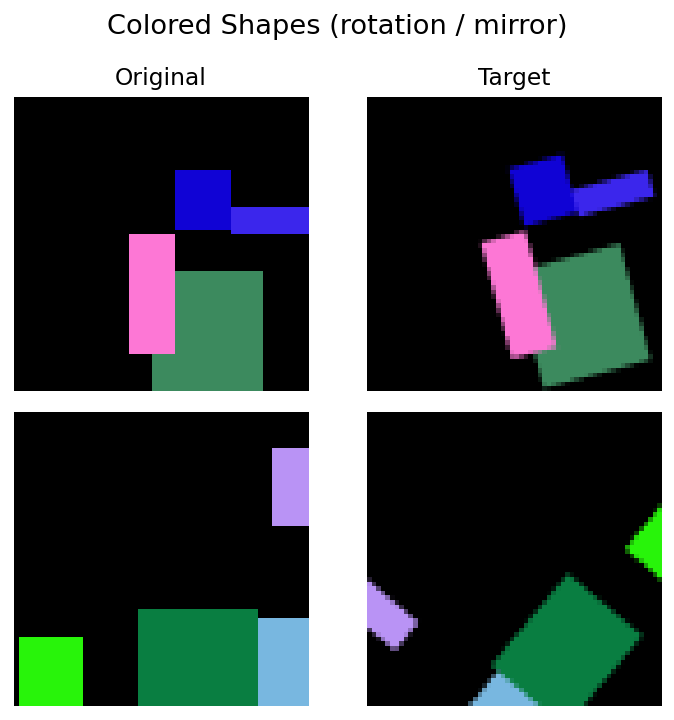

In [16]:
# --- Colored shapes dataset (rotation + optional mirror) ---
def random_colored_rectangles(h, w, num_shapes, rng):
    img = np.zeros((h, w, 3), dtype=np.float32)
    for _ in range(num_shapes):
        color = np.array([rng.random(), rng.random(), rng.random()], dtype=np.float32)
        y0 = rng.randint(0, h - 8)
        x0 = rng.randint(0, w - 8)
        y1 = min(h, y0 + rng.randint(6, h // 2))
        x1 = min(w, x0 + rng.randint(6, w // 2))
        img[y0:y1, x0:x1] = color
    return img

def transform_color(img, angle_deg, mirror=False):
    src = np.flip(img, axis=1) if mirror else img
    rot = rotate_image_np(src, angle_deg, mode="bilinear")
    return np.clip(rot, 0.0, 1.0)

def sample_color_rotation_pairs(size=64, num_shapes=4, seed=3):
    rng = random.Random(seed)

    base1 = random_colored_rectangles(size, size, num_shapes, rng)
    angle1 = rng.choice([15, 30, 45, 60, 75])
    pair1 = (base1, transform_color(base1, angle1, mirror=False))

    base2 = random_colored_rectangles(size, size, num_shapes, rng)
    angle2 = rng.choice([20, 35, 50, 65])
    pair2 = (base2, transform_color(base2, angle2, mirror=True))

    pairs = [pair1, pair2]
    row_titles = [f"Rotated ({angle1}°)", f"Rotated + Mirrored ({angle2}°)"]
    return pairs, row_titles

pairs, row_titles = sample_color_rotation_pairs(size=64, num_shapes=4, seed=3)
plot_pair_grid(pairs, "Colored Shapes (rotation / mirror)", row_titles=row_titles)


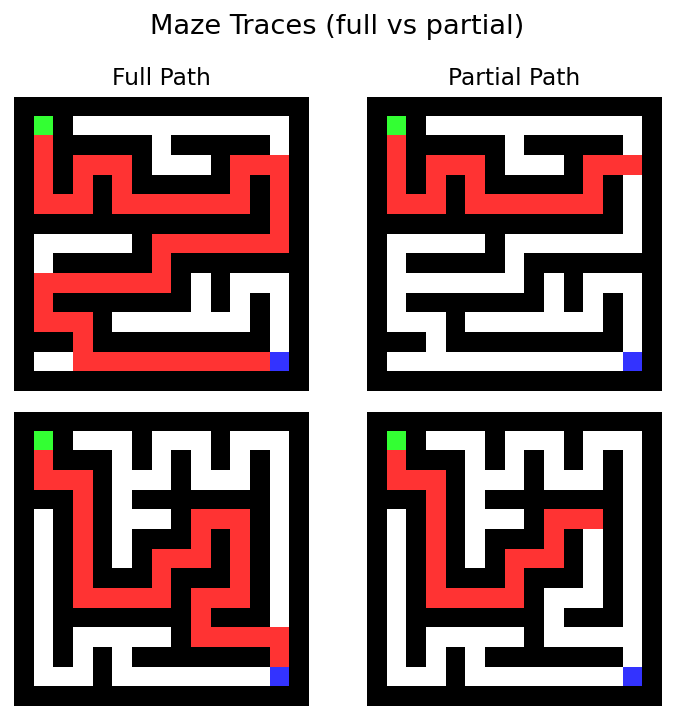

In [17]:
# --- Maze dataset (full vs partial path) ---
def generate_maze(cells_w, cells_h, rng):
    grid = np.ones((cells_h * 2 + 1, cells_w * 2 + 1), dtype=np.uint8)
    visited = np.zeros((cells_h, cells_w), dtype=bool)

    stack = [(0, 0)]
    visited[0, 0] = True
    grid[1, 1] = 0

    while stack:
        x, y = stack[-1]
        neighbors = []
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < cells_w and 0 <= ny < cells_h and not visited[ny, nx]:
                neighbors.append((nx, ny, dx, dy))
        if neighbors:
            nx, ny, dx, dy = rng.choice(neighbors)
            grid[y * 2 + 1 + dy, x * 2 + 1 + dx] = 0
            grid[ny * 2 + 1, nx * 2 + 1] = 0
            visited[ny, nx] = True
            stack.append((nx, ny))
        else:
            stack.pop()

    return grid

def bfs_shortest_path(grid, start, goal):
    h, w = grid.shape
    q = deque([start])
    prev = {start: None}

    while q:
        y, x = q.popleft()
        if (y, x) == goal:
            break
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and grid[ny, nx] == 0:
                if (ny, nx) not in prev:
                    prev[(ny, nx)] = (y, x)
                    q.append((ny, nx))

    if goal not in prev:
        return []

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()
    return path

def render_maze(grid, start, goal, trace_nodes=None):
    h, w = grid.shape
    img = np.ones((h, w, 3), dtype=np.float32)
    img[grid == 1] = 0.0
    if trace_nodes:
        for y, x in trace_nodes:
            img[y, x] = np.array([1.0, 0.2, 0.2], dtype=np.float32)
    sy, sx = start
    gy, gx = goal
    img[sy, sx] = np.array([0.2, 1.0, 0.2], dtype=np.float32)
    img[gy, gx] = np.array([0.2, 0.2, 1.0], dtype=np.float32)
    return img

def sample_maze_pairs(n=2, cells=7, seed=5):
    rng = random.Random(seed)
    pairs = []
    row_titles = []
    for i in range(n):
        for _attempt in range(20):
            grid = generate_maze(cells, cells, rng)
            start = (1, 1)
            goal = (grid.shape[0] - 2, grid.shape[1] - 2)
            path = bfs_shortest_path(grid, start, goal)
            if len(path) >= 4:
                break
        if len(path) < 4:
            continue
        k = rng.randint(2, len(path) - 2)
        full = render_maze(grid, start, goal, path)
        partial = render_maze(grid, start, goal, path[:k])
        pairs.append((full, partial))
        row_titles.append(f"Sample {i + 1} ({k}/{len(path)} steps)")
    return pairs, row_titles

pairs, row_titles = sample_maze_pairs(n=2, cells=7, seed=5)
plot_pair_grid(
    pairs,
    "Maze Traces (full vs partial)",
    row_titles=row_titles,
    col_titles=("Full Path", "Partial Path"),
)
